# Brain2 Radial Kernel Training

Focused notebook for `data_brain2/kaggle_3m`.

This keeps only the workflow needed for a single radial kernel:

1. Build paired image/mask records from the LGG MRI `.tif` dataset.
2. Split by patient folder to avoid slice leakage.
3. Sample balanced tumor and non-tumor patches from masks.
4. Train one signed radial kernel profile `f(r)` with the same progressive/smooth regularized style used near the end of `radial_single_kernel_fi_optimization_tissue_mask.ipynb`.
5. Visualize the learned kernel, radial profile, validation curves, and a heatmap overlay on a full MRI slice.

Nothing in this notebook runs automatically beyond the cell you execute.

In [15]:
from pathlib import Path
import json
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from scipy.ndimage import binary_dilation, binary_erosion, gaussian_filter
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# Dataset
DATASET_ROOT = Path("data_brain2/kaggle_3m")
PATCH_OUTPUT_ROOT = Path("data_brain2/patches_radial_v2_p64_strict")
OUT_DIR = Path("results/brain2_radial_single_kernel")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Patch generation. Set RUN_PATCH_PREP=True when you want to regenerate patch folders.
RUN_PATCH_PREP = False
CLEAR_PATCH_OUTPUT_BEFORE_PREP = False
PATCH_SIZE = 64
N_POS_PER_IMAGE = 8
N_NEG_PER_IMAGE = 8
MAX_TRIES_PER_IMAGE = 300
MIN_POS_COVERAGE = 0.80
MAX_NEG_COVERAGE = 0.0
NEAR_NEG_FRACTION = 0.25
NEAR_NEG_DILATION = 12
MIN_TISSUE_FRACTION = 0.40
TISSUE_THRESHOLD = 5
MASK_THRESHOLD = 0
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
SPLIT_SEED = 42
MAX_SOURCE_IMAGES = None  # e.g. 1200 for a quick run; None uses all pairs
MAX_PATCHES_TRAIN_PER_CLASS = 3000
MAX_PATCHES_VAL_PER_CLASS = 1000
MAX_PATCHES_TEST_PER_CLASS = 1000

# Training
RESIZE_PATCH = 64
MAX_PER_CLASS = None  # None loads all generated patches; set smaller for a quick run
KERNEL_SIZE = 63
LEARNED_RADIUS_MAX = 30
NUM_RADIAL_KERNELS = 4
HEAD_HIDDEN_DIM = 32
HEAD_DROPOUT = 0.10
STANDARDIZE_PATCHES = True
FEATURE_MODE = "multi"  # "multi" uses mean_abs + abs_max + signed_topk from one radial kernel
RESPONSE_MODE = "signed_topk"  # used only when FEATURE_MODE="single"
SIGNED_TOPK_FRAC = 0.01
EPOCHS = 40
BATCH_SIZE = 128
LR_PROFILE = 1e-2
LR_HEAD = 3e-3
LAMBDA_SMOOTH = 1e-4
LAMBDA_CURVATURE = 1e-4
LAMBDA_ANCHOR = 1e-4
LAMBDA_SCALE = 1e-4
THRESHOLD_GRID_SIZE = 181

# Heatmap
EXAMPLE_IMAGE_PATH = None  # None picks the first positive-mask test/val/train slice
HEATMAP_SMOOTH_SIGMA = 1.2
EXACT_HEATMAP_STRIDE = 4
HEATMAP_N_EXAMPLES = 6
DENSE_OVERLAY_ALPHA = 0.42
SAVE_ARTIFACTS = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(min(8, max(1, os.cpu_count() or 1)))
print(f"Device: {DEVICE}")

Device: cuda


In [16]:
def image_to_gray_float(path: Path) -> np.ndarray:
    arr = np.array(Image.open(path).convert("L"), dtype=np.float32)
    return arr / 255.0


def mask_to_bool(path: Path, shape=None) -> np.ndarray:
    mask = np.array(Image.open(path).convert("L"), dtype=np.uint8)
    if shape is not None and mask.shape != shape:
        mask_img = Image.fromarray(mask).resize((shape[1], shape[0]), resample=Image.Resampling.NEAREST)
        mask = np.array(mask_img, dtype=np.uint8)
    return mask > int(MASK_THRESHOLD)


def list_image_mask_pairs(dataset_root: Path):
    dataset_root = Path(dataset_root)
    pairs = []
    for patient_dir in sorted(p for p in dataset_root.iterdir() if p.is_dir()):
        for image_path in sorted(patient_dir.glob("*.tif")):
            if image_path.name.endswith("_mask.tif"):
                continue
            mask_path = image_path.with_name(f"{image_path.stem}_mask.tif")
            if mask_path.exists():
                pairs.append({
                    "patient": patient_dir.name,
                    "image": image_path,
                    "mask": mask_path,
                    "stem": image_path.stem,
                })
    if not pairs:
        raise FileNotFoundError(f"No image/mask .tif pairs found under {dataset_root}")
    return pairs


def split_patients(pairs, train_frac=0.70, val_frac=0.15, seed=42):
    patients = sorted({row["patient"] for row in pairs})
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(patients))
    n_train = int(round(train_frac * len(patients)))
    n_val = int(round(val_frac * len(patients)))
    split_by_patient = {}
    for pos, idx in enumerate(order):
        if pos < n_train:
            split = "train"
        elif pos < n_train + n_val:
            split = "val"
        else:
            split = "test"
        split_by_patient[patients[idx]] = split
    return split_by_patient


def crop_with_padding(arr: np.ndarray, cy: int, cx: int, patch_size: int, pad_value: float = 0.0):
    half = patch_size // 2
    y0, y1 = cy - half, cy - half + patch_size
    x0, x1 = cx - half, cx - half + patch_size
    out = np.full((patch_size, patch_size), pad_value, dtype=arr.dtype)
    sy0, sy1 = max(0, y0), min(arr.shape[0], y1)
    sx0, sx1 = max(0, x0), min(arr.shape[1], x1)
    oy0, ox0 = sy0 - y0, sx0 - x0
    out[oy0:oy0 + (sy1 - sy0), ox0:ox0 + (sx1 - sx0)] = arr[sy0:sy1, sx0:sx1]
    return out


def sample_class_patches(
    img: np.ndarray,
    tumor_mask: np.ndarray,
    candidate_mask: np.ndarray,
    n_patches: int,
    patch_size: int,
    max_tries: int,
    min_tissue_fraction: float,
    is_positive: bool,
):
    yy, xx = np.nonzero(candidate_mask)
    if len(yy) == 0 or n_patches <= 0:
        return []

    tissue = img > (float(TISSUE_THRESHOLD) / 255.0)
    rng = np.random.default_rng()
    patches = []
    for _ in range(max_tries):
        if len(patches) >= n_patches:
            break
        j = int(rng.integers(0, len(yy)))
        cy, cx = int(yy[j]), int(xx[j])
        patch = crop_with_padding(img, cy, cx, patch_size, pad_value=0.0)
        tumor_patch = crop_with_padding(tumor_mask.astype(np.float32), cy, cx, patch_size, pad_value=0.0) > 0.5
        tissue_patch = crop_with_padding(tissue.astype(np.float32), cy, cx, patch_size, pad_value=0.0) > 0.5

        tumor_frac = float(tumor_patch.mean())
        tissue_frac = float(tissue_patch.mean())
        if tissue_frac < float(min_tissue_fraction):
            continue
        if is_positive and tumor_frac < float(MIN_POS_COVERAGE):
            continue
        if (not is_positive) and tumor_frac > float(MAX_NEG_COVERAGE):
            continue
        patches.append((patch * 255.0).clip(0, 255).astype(np.uint8))
    return patches


def prepare_patch_splits():
    if CLEAR_PATCH_OUTPUT_BEFORE_PREP and PATCH_OUTPUT_ROOT.exists():
        shutil.rmtree(PATCH_OUTPUT_ROOT)

    pairs = list_image_mask_pairs(DATASET_ROOT)
    split_by_patient = split_patients(pairs, TRAIN_FRAC, VAL_FRAC, SPLIT_SEED)

    rng = np.random.default_rng(SPLIT_SEED)
    if MAX_SOURCE_IMAGES is not None and len(pairs) > int(MAX_SOURCE_IMAGES):
        pairs = [pairs[i] for i in rng.permutation(len(pairs))[: int(MAX_SOURCE_IMAGES)]]

    for split in ("train", "val", "test"):
        (PATCH_OUTPUT_ROOT / split / "inside").mkdir(parents=True, exist_ok=True)
        (PATCH_OUTPUT_ROOT / split / "outside").mkdir(parents=True, exist_ok=True)

    caps = {
        "train": MAX_PATCHES_TRAIN_PER_CLASS,
        "val": MAX_PATCHES_VAL_PER_CLASS,
        "test": MAX_PATCHES_TEST_PER_CLASS,
    }
    counts = {split: {"inside": 0, "outside": 0} for split in ("train", "val", "test")}

    def class_full(split, cls):
        cap = caps[split]
        return cap is not None and counts[split][cls] >= int(cap)

    for row in tqdm(pairs, desc="Sampling Brain2 patches"):
        split = split_by_patient[row["patient"]]
        if class_full(split, "inside") and class_full(split, "outside"):
            continue

        img = image_to_gray_float(row["image"])
        tumor = mask_to_bool(row["mask"], shape=img.shape)
        tissue = img > (float(TISSUE_THRESHOLD) / 255.0)
        if not tumor.any():
            pos_candidates = np.zeros_like(tumor, dtype=bool)
        else:
            pos_candidates = tumor

        dilated = binary_dilation(tumor, iterations=int(NEAR_NEG_DILATION)) if tumor.any() else np.zeros_like(tumor)
        near_negative = tissue & dilated & ~tumor
        far_negative = tissue & ~tumor

        n_pos = 0 if class_full(split, "inside") else int(N_POS_PER_IMAGE)
        n_neg = 0 if class_full(split, "outside") else int(N_NEG_PER_IMAGE)
        n_near = int(round(n_neg * float(NEAR_NEG_FRACTION)))
        n_far = max(0, n_neg - n_near)

        pos_patches = sample_class_patches(img, tumor, pos_candidates, n_pos, PATCH_SIZE, MAX_TRIES_PER_IMAGE, MIN_TISSUE_FRACTION, True)
        neg_patches = []
        neg_patches.extend(sample_class_patches(img, tumor, near_negative, n_near, PATCH_SIZE, MAX_TRIES_PER_IMAGE, MIN_TISSUE_FRACTION, False))
        if len(neg_patches) < n_neg:
            neg_patches.extend(sample_class_patches(img, tumor, far_negative, n_neg - len(neg_patches), PATCH_SIZE, MAX_TRIES_PER_IMAGE, MIN_TISSUE_FRACTION, False))

        for cls, patches in (("inside", pos_patches), ("outside", neg_patches)):
            for patch in patches:
                if class_full(split, cls):
                    break
                idx = counts[split][cls]
                out_path = PATCH_OUTPUT_ROOT / split / cls / f"{cls}_{row['stem']}_{idx:05d}.tif"
                Image.fromarray(patch).save(out_path)
                counts[split][cls] += 1

    summary = {
        "dataset_root": str(DATASET_ROOT),
        "patch_output_root": str(PATCH_OUTPUT_ROOT),
        "n_pairs_used": len(pairs),
        "n_patients": len(set(split_by_patient)),
        "split_counts": counts,
        "config": {
            "patch_size": PATCH_SIZE,
            "n_pos_per_image": N_POS_PER_IMAGE,
            "n_neg_per_image": N_NEG_PER_IMAGE,
            "min_pos_coverage": MIN_POS_COVERAGE,
            "max_neg_coverage": MAX_NEG_COVERAGE,
            "near_neg_fraction": NEAR_NEG_FRACTION,
            "near_neg_dilation": NEAR_NEG_DILATION,
        },
    }
    PATCH_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    (PATCH_OUTPUT_ROOT / "prep_summary.json").write_text(json.dumps(summary, indent=2))
    return summary

pairs = list_image_mask_pairs(DATASET_ROOT)
print(f"Found {len(pairs)} image/mask pairs from {len({row['patient'] for row in pairs})} patients")
print(pairs[0])

Found 3929 image/mask pairs from 110 patients
{'patient': 'TCGA_CS_4941_19960909', 'image': PosixPath('data_brain2/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1.tif'), 'mask': PosixPath('data_brain2/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1_mask.tif'), 'stem': 'TCGA_CS_4941_19960909_1'}


In [17]:
print(f"Patch output root: {PATCH_OUTPUT_ROOT}")
print(f"Results output root: {OUT_DIR}")
print("If you changed patch-generation settings, set RUN_PATCH_PREP=True and regenerate patches before training.")


Patch output root: data_brain2/patches_radial_v2_p64_strict
Results output root: results/brain2_radial_single_kernel
If you changed patch-generation settings, set RUN_PATCH_PREP=True and regenerate patches before training.


In [18]:
if RUN_PATCH_PREP:
    prep_summary = prepare_patch_splits()
    print(json.dumps(prep_summary, indent=2))
else:
    print("RUN_PATCH_PREP=False. Set it to True and run this cell if patch folders are missing or stale.")
    for split in ("train", "val", "test"):
        for cls in ("inside", "outside"):
            n = len(list((PATCH_OUTPUT_ROOT / split / cls).glob("*.tif"))) if (PATCH_OUTPUT_ROOT / split / cls).exists() else 0
            print(f"{split:5s}/{cls:7s}: {n}")

RUN_PATCH_PREP=False. Set it to True and run this cell if patch folders are missing or stale.
train/inside : 3000
train/outside: 3000
val  /inside : 1000
val  /outside: 1000
test /inside : 1000
test /outside: 1000


In [19]:
def load_patch_folder(folder: Path, resize: int | None = None, max_count: int | None = None):
    paths = sorted(Path(folder).glob("*.tif"))
    if max_count is not None:
        paths = paths[: int(max_count)]
    arrs = []
    for p in tqdm(paths, desc=f"Loading {folder}"):
        img = Image.open(p).convert("L")
        if resize is not None and img.size != (resize, resize):
            img = img.resize((resize, resize), resample=Image.Resampling.BILINEAR)
        arrs.append(np.array(img, dtype=np.float32) / 255.0)
    if not arrs:
        return np.zeros((0, resize or PATCH_SIZE, resize or PATCH_SIZE), dtype=np.float32)
    return np.stack(arrs, axis=0).astype(np.float32)


def load_split(root: Path, split: str, resize: int, max_per_class: int | None = None):
    Xin = load_patch_folder(root / split / "inside", resize=resize, max_count=max_per_class)
    Xout = load_patch_folder(root / split / "outside", resize=resize, max_count=max_per_class)
    if len(Xin) == 0 or len(Xout) == 0:
        raise ValueError(f"Split {split} needs both classes. Got inside={len(Xin)} outside={len(Xout)}")
    return Xin, Xout


def to_tensor_batch(x_np: np.ndarray, device=torch.device("cpu")):
    x_t = torch.from_numpy(x_np.astype(np.float32))
    if x_t.ndim == 3:
        x_t = x_t[:, None, :, :]
    return x_t.to(device)


def patch_standardize(x_t: torch.Tensor):
    mean = x_t.mean(dim=(2, 3), keepdim=True)
    std = x_t.std(dim=(2, 3), keepdim=True)
    std = torch.where(std < 1e-6, torch.ones_like(std), std)
    return (x_t - mean) / std


def make_xy_tensors(Xin_np: np.ndarray, Xout_np: np.ndarray, standardize: bool):
    X = np.concatenate([Xin_np, Xout_np], axis=0).astype(np.float32)
    y = np.concatenate([
        np.ones(len(Xin_np), dtype=np.float32),
        np.zeros(len(Xout_np), dtype=np.float32),
    ])
    X_t = to_tensor_batch(X, torch.device("cpu"))
    if standardize:
        X_t = patch_standardize(X_t)
    y_t = torch.from_numpy(y)
    return X_t.contiguous(), y_t.contiguous(), y.astype(np.int64)

Xin_train, Xout_train = load_split(PATCH_OUTPUT_ROOT, "train", RESIZE_PATCH, MAX_PER_CLASS)
Xin_val, Xout_val = load_split(PATCH_OUTPUT_ROOT, "val", RESIZE_PATCH, MAX_PER_CLASS)
Xin_test, Xout_test = load_split(PATCH_OUTPUT_ROOT, "test", RESIZE_PATCH, MAX_PER_CLASS)

X_train_t, y_train_t, y_train = make_xy_tensors(Xin_train, Xout_train, STANDARDIZE_PATCHES)
X_val_t, y_val_t, y_val = make_xy_tensors(Xin_val, Xout_val, STANDARDIZE_PATCHES)
X_test_t, y_test_t, y_test = make_xy_tensors(Xin_test, Xout_test, STANDARDIZE_PATCHES)

def print_split_balance(name: str, y: np.ndarray):
    counts = np.bincount(y, minlength=2)
    neg, pos = int(counts[0]), int(counts[1])
    total = max(1, neg + pos)
    majority = max(neg, pos) / total
    print(f"  {name:5s} neg={neg:5d} pos={pos:5d} majority_baseline={majority:.3f}")
    if neg == 0 or pos == 0:
        raise ValueError(f"{name} split has an empty class: neg={neg}, pos={pos}")
    if max(neg, pos) / max(1, min(neg, pos)) > 1.25:
        print(f"    warning: {name} split is imbalanced; BCE and logistic calibration use class balancing.")

print("Patch tensors:")
print("  train", tuple(X_train_t.shape))
print("  val  ", tuple(X_val_t.shape))
print("  test ", tuple(X_test_t.shape))
print("Class balance:")
print_split_balance("train", y_train)
print_split_balance("val", y_val)
print_split_balance("test", y_test)

Loading data_brain2/patches_radial_v2_p64_strict/train/inside: 100%|██████████| 3000/3000 [00:01<00:00, 2590.93it/s]
Loading data_brain2/patches_radial_v2_p64_strict/train/outside: 100%|██████████| 3000/3000 [00:01<00:00, 2502.52it/s]
Loading data_brain2/patches_radial_v2_p64_strict/val/inside: 100%|██████████| 1000/1000 [00:00<00:00, 2174.56it/s]
Loading data_brain2/patches_radial_v2_p64_strict/val/outside: 100%|██████████| 1000/1000 [00:00<00:00, 1824.08it/s]
Loading data_brain2/patches_radial_v2_p64_strict/test/inside: 100%|██████████| 1000/1000 [00:00<00:00, 2071.38it/s]
Loading data_brain2/patches_radial_v2_p64_strict/test/outside: 100%|██████████| 1000/1000 [00:00<00:00, 2519.22it/s]


Patch tensors:
  train (6000, 1, 64, 64)
  val   (2000, 1, 64, 64)
  test  (2000, 1, 64, 64)
Class balance:
  train neg= 3000 pos= 3000 majority_baseline=0.500
  val   neg= 1000 pos= 1000 majority_baseline=0.500
  test  neg= 1000 pos= 1000 majority_baseline=0.500


In [20]:
def integer_radius_bins(kernel_shape):
    h, w = kernel_shape
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w))
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    return np.floor(r).astype(np.int64)


def build_radial_basis(radius_bins: np.ndarray):
    max_r = int(radius_bins.max())
    return np.stack([(radius_bins == i).astype(np.float32) for i in range(max_r + 1)], axis=0)


def make_seed_profile(max_radius: int):
    r = np.arange(max_radius + 1, dtype=np.float32)
    # Smooth signed center-surround initialization. Training is free to move the profile.
    center = np.exp(-(r / 5.0) ** 2)
    surround = 0.45 * np.exp(-((r - 12.0) / 7.0) ** 2)
    profile = center - surround
    profile[r > LEARNED_RADIUS_MAX] = 0.0
    norm = np.linalg.norm(profile)
    if norm > 1e-8:
        profile = profile / norm
    return profile.astype(np.float32)


def response_feature_names():
    if FEATURE_MODE == "multi":
        return ("mean_abs", "abs_max", "signed_topk")
    if FEATURE_MODE == "single":
        if RESPONSE_MODE not in {"mean_abs", "abs_max", "signed_topk"}:
            raise ValueError(f"Unknown RESPONSE_MODE={RESPONSE_MODE!r}")
        return (RESPONSE_MODE,)
    raise ValueError(f"Unknown FEATURE_MODE={FEATURE_MODE!r}")


RESPONSE_FEATURE_NAMES = response_feature_names()


def features_from_conv(conv_t: torch.Tensor, feature_names=RESPONSE_FEATURE_NAMES):
    flat = conv_t[:, 0].flatten(start_dim=1)
    out = []
    for name in feature_names:
        if name == "mean_abs":
            out.append(conv_t.abs().mean(dim=(2, 3))[:, 0])
        elif name == "abs_max":
            out.append(conv_t.abs().amax(dim=(2, 3))[:, 0])
        elif name == "signed_topk":
            k = max(1, int(round(flat.shape[1] * float(SIGNED_TOPK_FRAC))))
            pos = flat.topk(k, dim=1).values.mean(dim=1)
            neg = (-flat).topk(k, dim=1).values.mean(dim=1)
            out.append(pos - neg)
        else:
            raise ValueError(f"Unknown response feature {name!r}")
    return torch.stack(out, dim=1)


def response_features_from_kernel(x_t: torch.Tensor, kernel2d_t: torch.Tensor):
    conv = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    return features_from_conv(conv)


def response_from_kernel(x_t: torch.Tensor, kernel2d_t: torch.Tensor, mode: str):
    conv = F.conv2d(x_t, kernel2d_t[None, None], padding=kernel2d_t.shape[-1] // 2)
    return features_from_conv(conv, (mode,))[:, 0]


@torch.no_grad()
def extract_response_features(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    kernel2d_t = kernel2d_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = response_features_from_kernel(xb, kernel2d_t)
        feats.append(feat.detach().cpu().numpy())
    if not feats:
        return np.zeros((0, len(RESPONSE_FEATURE_NAMES)), dtype=np.float32)
    return np.concatenate(feats, axis=0).astype(np.float32)


@torch.no_grad()
def extract_responses(x_t: torch.Tensor, kernel2d_t: torch.Tensor, batch_size: int):
    feats = extract_response_features(x_t, kernel2d_t, batch_size)
    return feats[:, 0] if feats.shape[1] == 1 else feats

def metrics_from_probs(y_true: np.ndarray, probs: np.ndarray, threshold: float = 0.5):
    y_hat = (probs > float(threshold)).astype(np.int64)
    acc = accuracy_score(y_true, y_hat)
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) > 1 else float("nan")
    return {"acc": float(acc), "auc": float(auc)}


def best_threshold_by_accuracy(y_true: np.ndarray, probs: np.ndarray, grid_size: int = 181):
    grid = np.linspace(0.05, 0.95, int(grid_size), dtype=np.float32)
    preds = probs[None, :] > grid[:, None]
    accs = (preds == y_true[None, :]).mean(axis=1)
    best_idx = int(np.argmax(accs))
    return float(grid[best_idx]), float(accs[best_idx])


def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

radius_bins = integer_radius_bins((KERNEL_SIZE, KERNEL_SIZE))
basis_np = build_radial_basis(radius_bins).astype(np.float32)
full_radius_count = basis_np.shape[0]
f_seed_full = make_seed_profile(full_radius_count - 1)
seed_radial_kernel = np.einsum("r,rhw->hw", f_seed_full, basis_np).astype(np.float32)

basis_t = torch.from_numpy(basis_np).to(DEVICE)
print(f"Kernel size: {KERNEL_SIZE}x{KERNEL_SIZE}")
print(f"Total radial shells: {full_radius_count}")
print(f"Learned shells: 0..{min(LEARNED_RADIUS_MAX, full_radius_count - 1)}")
print(f"Response features: {RESPONSE_FEATURE_NAMES}")

Kernel size: 63x63
Total radial shells: 44
Learned shells: 0..30
Response features: ('mean_abs', 'abs_max', 'signed_topk')


In [21]:
# Radial-kernel bank training.
# This keeps the model radial, but gives it multiple independent radial profiles instead of one scalar detector.
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)

learnable_len = min(int(LEARNED_RADIUS_MAX), full_radius_count - 1) + 1
f_seed_learn = f_seed_full[:learnable_len].copy()
f_tail_fixed = f_seed_full[learnable_len:].copy()
seed_norm = float(np.linalg.norm(f_seed_full))

rng = np.random.default_rng(SPLIT_SEED)
f_seed_bank = []
base = f_seed_learn.astype(np.float32)
for k in range(int(NUM_RADIAL_KERNELS)):
    shift = int((k % 5) - 2)
    scale = 0.75 + 0.10 * (k % 6)
    variant = np.roll(base, shift) * scale
    variant += rng.normal(0.0, 0.05, size=variant.shape).astype(np.float32)
    if shift > 0:
        variant[:shift] = base[:shift]
    elif shift < 0:
        variant[shift:] = base[shift:]
    f_seed_bank.append(variant.astype(np.float32))
f_seed_bank = np.stack(f_seed_bank, axis=0).astype(np.float32)

f_seed_bank_t = torch.from_numpy(f_seed_bank).to(DEVICE)
f_tail_fixed_t = torch.from_numpy(f_tail_fixed).to(DEVICE)
f_bank = torch.nn.Parameter(f_seed_bank_t.clone())


def build_kernels(f_bank_t: torch.Tensor):
    if f_tail_fixed_t.numel() > 0:
        tail = f_tail_fixed_t[None, :].expand(f_bank_t.shape[0], -1)
        f_full_t = torch.cat([f_bank_t, tail], dim=1)
    else:
        f_full_t = f_bank_t
    kernels_t = torch.einsum("kr,rhw->khw", f_full_t, basis_t)
    return kernels_t, f_full_t


def bank_response_features(x_t: torch.Tensor, kernels_t: torch.Tensor):
    conv = F.conv2d(x_t, kernels_t[:, None], padding=kernels_t.shape[-1] // 2)
    flat = conv.flatten(start_dim=2)
    feats = []
    for name in RESPONSE_FEATURE_NAMES:
        if name == "mean_abs":
            feats.append(conv.abs().mean(dim=(2, 3)))
        elif name == "abs_max":
            feats.append(conv.abs().amax(dim=(2, 3)))
        elif name == "signed_topk":
            k_top = max(1, int(round(flat.shape[-1] * float(SIGNED_TOPK_FRAC))))
            pos = flat.topk(k_top, dim=2).values.mean(dim=2)
            neg = (-flat).topk(k_top, dim=2).values.mean(dim=2)
            feats.append(pos - neg)
        else:
            raise ValueError(f"Unknown response feature {name!r}")
    return torch.cat(feats, dim=1)


@torch.no_grad()
def extract_bank_features(x_t: torch.Tensor, kernels_t: torch.Tensor, batch_size: int):
    kernels_t = kernels_t.to(DEVICE)
    feats = []
    for i in range(0, x_t.shape[0], batch_size):
        xb = x_t[i : i + batch_size].to(DEVICE, non_blocking=True)
        feat = bank_response_features(xb, kernels_t)
        feats.append(feat.detach().cpu().numpy())
    return np.concatenate(feats, axis=0).astype(np.float32) if feats else np.zeros((0, int(NUM_RADIAL_KERNELS) * len(RESPONSE_FEATURE_NAMES)), dtype=np.float32)


with torch.no_grad():
    seed_kernels_for_norm_t, _ = build_kernels(f_seed_bank_t)
opt_feat_ref = extract_bank_features(X_train_t, seed_kernels_for_norm_t.detach(), BATCH_SIZE)
opt_feat_mu = opt_feat_ref.mean(axis=0).astype(np.float32)
opt_feat_std = opt_feat_ref.std(axis=0).astype(np.float32)
opt_feat_std = np.where(opt_feat_std > 1e-8, opt_feat_std, 1.0).astype(np.float32)
opt_feat_mu_t = torch.from_numpy(opt_feat_mu).to(DEVICE)
opt_feat_std_t = torch.from_numpy(opt_feat_std).to(DEVICE)
print(f"Optimizer feature normalization: {opt_feat_ref.shape[1]} features from {NUM_RADIAL_KERNELS} radial kernels")

head = torch.nn.Sequential(
    torch.nn.Linear(opt_feat_ref.shape[1], int(HEAD_HIDDEN_DIM)),
    torch.nn.ReLU(),
    torch.nn.Dropout(float(HEAD_DROPOUT)),
    torch.nn.Linear(int(HEAD_HIDDEN_DIM), 1),
).to(DEVICE)

optimizer = torch.optim.Adam([
    {"params": [f_bank], "lr": LR_PROFILE},
    {"params": head.parameters(), "lr": LR_HEAD},
])

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
pos_weight = torch.tensor([n_neg / max(1, n_pos)], dtype=torch.float32, device=DEVICE)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"BCE pos_weight={float(pos_weight.cpu()[0]):.3f}")

best_state = None
best_val_auc = -float("inf")
history = []

for epoch in range(1, EPOCHS + 1):
    total_loss = 0.0
    total_cls_loss = 0.0
    n_seen = 0
    head.train()
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        kernels_t, f_full_t = build_kernels(f_bank)
        feat_raw = bank_response_features(xb, kernels_t)
        feat = (feat_raw - opt_feat_mu_t) / opt_feat_std_t
        logits = head(feat).squeeze(1)
        loss_cls = loss_fn(logits, yb)

        loss_smooth = torch.mean((f_full_t[:, 1:] - f_full_t[:, :-1]) ** 2)
        loss_curvature = torch.mean((f_full_t[:, 2:] - 2.0 * f_full_t[:, 1:-1] + f_full_t[:, :-2]) ** 2)
        loss_anchor = torch.mean((f_bank - f_seed_bank_t) ** 2)
        norms = torch.linalg.norm(f_full_t, dim=1)
        loss_scale = torch.mean((norms - seed_norm) ** 2)
        loss_diversity = torch.mean(torch.exp(-torch.pdist(f_bank, p=2).pow(2))) if f_bank.shape[0] > 1 else torch.tensor(0.0, device=DEVICE)
        loss = (
            loss_cls
            + LAMBDA_SMOOTH * loss_smooth
            + LAMBDA_CURVATURE * loss_curvature
            + LAMBDA_ANCHOR * loss_anchor
            + LAMBDA_SCALE * loss_scale
            + 1e-4 * loss_diversity
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_n = xb.shape[0]
        total_loss += float(loss.item()) * batch_n
        total_cls_loss += float(loss_cls.item()) * batch_n
        n_seen += batch_n

    head.eval()
    with torch.no_grad():
        kernels_eval_t, _ = build_kernels(f_bank)
        val_feat_raw = extract_bank_features(X_val_t, kernels_eval_t.detach(), BATCH_SIZE)
        val_feat = (val_feat_raw - opt_feat_mu) / opt_feat_std
        val_logits = head(torch.from_numpy(val_feat).to(DEVICE)).squeeze(1).detach().cpu().numpy()
        val_probs = sigmoid_np(val_logits)
        val_metrics = metrics_from_probs(y_val, val_probs, threshold=0.5)

    row = {
        "epoch": int(epoch),
        "loss": float(total_loss / max(n_seen, 1)),
        "cls_loss": float(total_cls_loss / max(n_seen, 1)),
        "val_auc": float(val_metrics["auc"]),
        "val_acc": float(val_metrics["acc"]),
    }
    history.append(row)

    if row["val_auc"] > best_val_auc:
        best_val_auc = row["val_auc"]
        best_state = {
            "epoch": int(epoch),
            "f_bank": f_bank.detach().cpu().clone(),
            "head_state": {k: v.detach().cpu().clone() for k, v in head.state_dict().items()},
            "val_auc": row["val_auc"],
            "val_acc": row["val_acc"],
        }

    print(
        f"epoch={epoch:02d} loss={row['loss']:.6f} cls={row['cls_loss']:.6f} "
        f"val_auc={row['val_auc']:.6f} val_acc={row['val_acc']:.6f}"
    )

print("\nBest checkpoint:")
print({k: v for k, v in best_state.items() if k not in {"head_state", "f_bank"}})

f_bank_best = best_state["f_bank"].to(DEVICE)
head.load_state_dict(best_state["head_state"])
head.to(DEVICE)
head.eval()
with torch.no_grad():
    kernels_best_t, f_best_full_t = build_kernels(f_bank_best)

f_best_full = f_best_full_t.detach().cpu().numpy().astype(np.float32)
kernel_best = kernels_best_t.detach().cpu().numpy().astype(np.float32)
# Backward-compatible aliases for plotting/saving logic.
f_best_full_bank = f_best_full
kernel_best_bank = kernel_best

train_feat = extract_bank_features(X_train_t, kernels_best_t.detach(), BATCH_SIZE)
val_feat = extract_bank_features(X_val_t, kernels_best_t.detach(), BATCH_SIZE)
test_feat = extract_bank_features(X_test_t, kernels_best_t.detach(), BATCH_SIZE)

calib_mu = train_feat.mean(axis=0).astype(np.float32)
calib_std = train_feat.std(axis=0).astype(np.float32)
calib_std = np.where(calib_std > 1e-8, calib_std, 1.0).astype(np.float32)

calib_clf = LogisticRegression(max_iter=2000, class_weight="balanced")
calib_clf.fit((train_feat - calib_mu) / calib_std, y_train)
calib_w = calib_clf.coef_[0].astype(np.float32)
calib_b = float(calib_clf.intercept_[0])

train_probs = calib_clf.predict_proba((train_feat - calib_mu) / calib_std)[:, 1]
val_probs = calib_clf.predict_proba((val_feat - calib_mu) / calib_std)[:, 1]
test_probs = calib_clf.predict_proba((test_feat - calib_mu) / calib_std)[:, 1]

threshold_val, val_acc_tuned = best_threshold_by_accuracy(y_val, val_probs, THRESHOLD_GRID_SIZE)
results = {
    "train_05": metrics_from_probs(y_train, train_probs, threshold=0.5),
    "val_05": metrics_from_probs(y_val, val_probs, threshold=0.5),
    "val_tuned": metrics_from_probs(y_val, val_probs, threshold=threshold_val),
    "test_05": metrics_from_probs(y_test, test_probs, threshold=0.5),
    "test_tuned": metrics_from_probs(y_test, test_probs, threshold=threshold_val),
    "threshold_val": float(threshold_val),
    "best_epoch": int(best_state["epoch"]),
    "num_radial_kernels": int(NUM_RADIAL_KERNELS),
    "response_feature_names": list(RESPONSE_FEATURE_NAMES),
    "optimizer_feature_mu": [float(x) for x in opt_feat_mu],
    "optimizer_feature_std": [float(x) for x in opt_feat_std],
    "calib_mu": [float(x) for x in calib_mu],
    "calib_std": [float(x) for x in calib_std],
    "calib_w": [float(x) for x in calib_w],
    "calib_b": calib_b,
}

print("\nCalibrated radial-kernel bank metrics:")
print(f"  Train| AUC={results['train_05']['auc']:.6f} ACC@0.5={results['train_05']['acc']:.6f}")
print(
    f"  Val  | AUC={results['val_05']['auc']:.6f} ACC@0.5={results['val_05']['acc']:.6f} "
    f"ACC@thr_val={results['val_tuned']['acc']:.6f} (thr_val={results['threshold_val']:.3f})"
)
print(
    f"  Test | AUC={results['test_05']['auc']:.6f} ACC@0.5={results['test_05']['acc']:.6f} "
    f"ACC@thr_val={results['test_tuned']['acc']:.6f}"
)

feature_labels = [f"k{k:02d}:{name}" for name in RESPONSE_FEATURE_NAMES for k in range(int(NUM_RADIAL_KERNELS))]
top_idx = np.argsort(np.abs(calib_w))[::-1][:12]
print("Top calibration weights:")
for idx in top_idx:
    print(f"  {feature_labels[idx]:16s} w={float(calib_w[idx]):+.4f} mu={float(calib_mu[idx]):+.5f} std={float(calib_std[idx]):.5f}")


Optimizer feature normalization: 12 features from 4 radial kernels
BCE pos_weight=1.000
epoch=01 loss=0.602955 cls=0.602893 val_auc=0.733745 val_acc=0.660000
epoch=02 loss=0.512986 cls=0.512939 val_auc=0.770912 val_acc=0.673000
epoch=03 loss=0.457472 cls=0.457427 val_auc=0.795057 val_acc=0.694500
epoch=04 loss=0.433762 cls=0.433712 val_auc=0.811179 val_acc=0.728500
epoch=05 loss=0.414119 cls=0.414061 val_auc=0.792922 val_acc=0.705000
epoch=06 loss=0.401733 cls=0.401668 val_auc=0.804516 val_acc=0.715000
epoch=07 loss=0.397772 cls=0.397705 val_auc=0.812449 val_acc=0.703500
epoch=08 loss=0.384386 cls=0.384318 val_auc=0.819885 val_acc=0.713500
epoch=09 loss=0.380614 cls=0.380544 val_auc=0.814246 val_acc=0.721500
epoch=10 loss=0.384258 cls=0.384185 val_auc=0.808690 val_acc=0.707000
epoch=11 loss=0.376117 cls=0.376044 val_auc=0.812896 val_acc=0.703000
epoch=12 loss=0.372054 cls=0.371976 val_auc=0.814956 val_acc=0.713000
epoch=13 loss=0.366489 cls=0.366409 val_auc=0.822243 val_acc=0.732000
ep

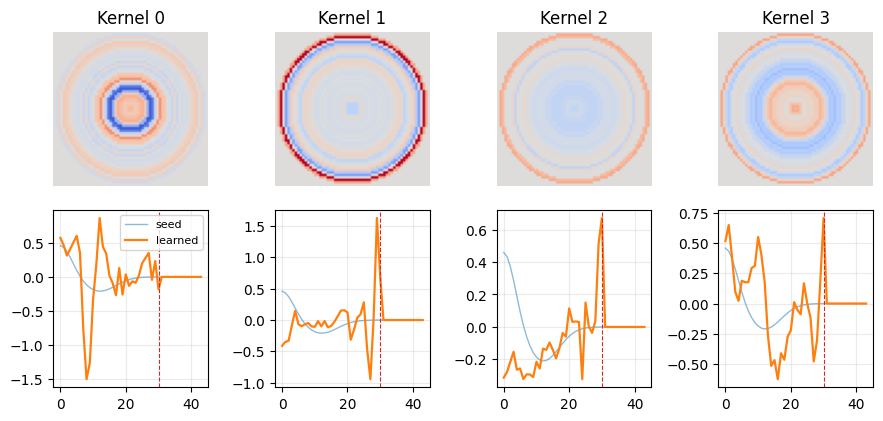

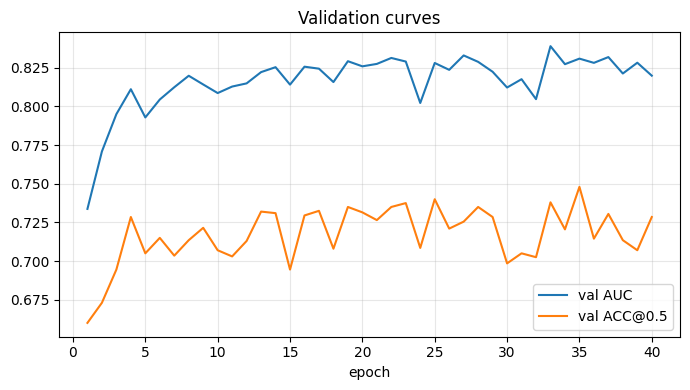

Saved radial-kernel bank artifacts to results/brain2_radial_single_kernel


In [22]:
n_show = min(int(NUM_RADIAL_KERNELS), 8)
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.4))
if n_show == 1:
    axes = np.array(axes).reshape(2, 1)
vmax = max(float(np.max(np.abs(seed_radial_kernel))), float(np.max(np.abs(kernel_best)))) + 1e-12
for k in range(n_show):
    axes[0, k].imshow(kernel_best[k], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[0, k].set_title(f"Kernel {k}")
    axes[0, k].axis("off")
    axes[1, k].plot(np.arange(len(f_seed_full)), f_seed_full, linewidth=1.0, alpha=0.5, label="seed")
    axes[1, k].plot(np.arange(f_best_full.shape[1]), f_best_full[k], linewidth=1.6, label="learned")
    axes[1, k].axvline(learnable_len - 1, color="tab:red", linestyle="--", linewidth=0.8)
    axes[1, k].grid(alpha=0.25)
    if k == 0:
        axes[1, k].legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
hist_epochs = np.array([row["epoch"] for row in history], dtype=int)
ax.plot(hist_epochs, [row["val_auc"] for row in history], label="val AUC")
ax.plot(hist_epochs, [row["val_acc"] for row in history], label="val ACC@0.5")
ax.set_xlabel("epoch")
ax.set_title("Validation curves")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / "kernel_seed_radial.npy", seed_radial_kernel.astype(np.float32))
    np.save(OUT_DIR / "kernels_learned_radial_bank.npy", kernel_best.astype(np.float32))
    np.save(OUT_DIR / "f_seed_full.npy", f_seed_full.astype(np.float32))
    np.save(OUT_DIR / "f_learned_full_bank.npy", f_best_full.astype(np.float32))
    summary = {
        "config": {
            "dataset_root": str(DATASET_ROOT),
            "patch_output_root": str(PATCH_OUTPUT_ROOT),
            "kernel_size": KERNEL_SIZE,
            "learned_radius_max": LEARNED_RADIUS_MAX,
            "num_radial_kernels": int(NUM_RADIAL_KERNELS),
            "feature_mode": FEATURE_MODE,
            "response_mode": RESPONSE_MODE,
            "response_feature_names": list(RESPONSE_FEATURE_NAMES),
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
        },
        "seed_profile": [float(x) for x in f_seed_full],
        "learned_profiles": [[float(x) for x in row] for row in f_best_full],
        "metrics": results,
        "history": history,
    }
    (OUT_DIR / "radial_kernel_bank_summary.json").write_text(json.dumps(summary, indent=2))
    print(f"Saved radial-kernel bank artifacts to {OUT_DIR}")


Rendering 6 heatmap examples


Exact heatmap rows: 100%|██████████| 49/49 [00:06<00:00,  7.91it/s]


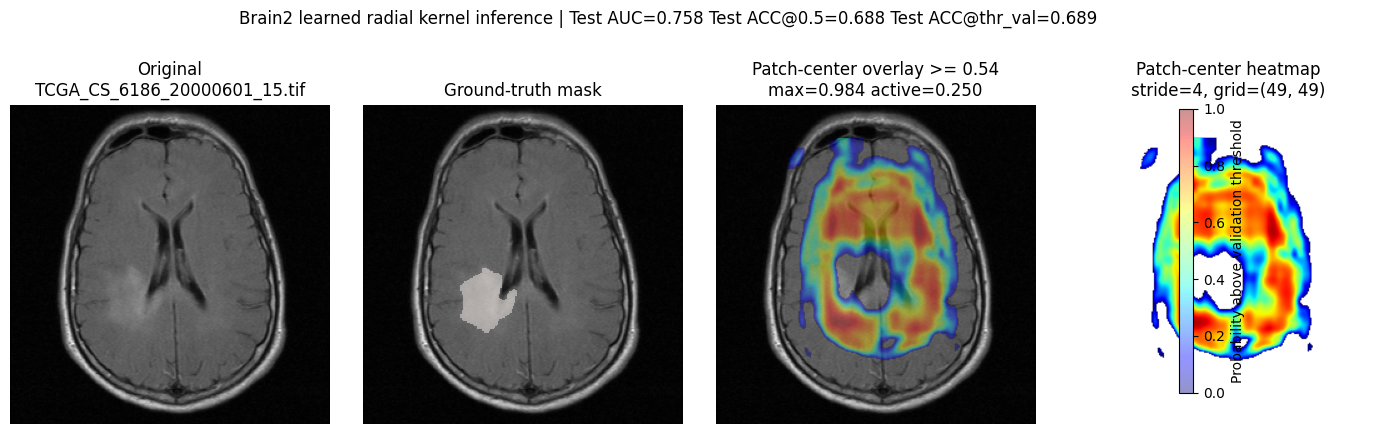

Patch-center heatmap raw probability: max=0.983776 mean=0.549861 active_frac=0.250183 grid=(49, 49)


Exact heatmap rows: 100%|██████████| 49/49 [00:06<00:00,  7.95it/s]


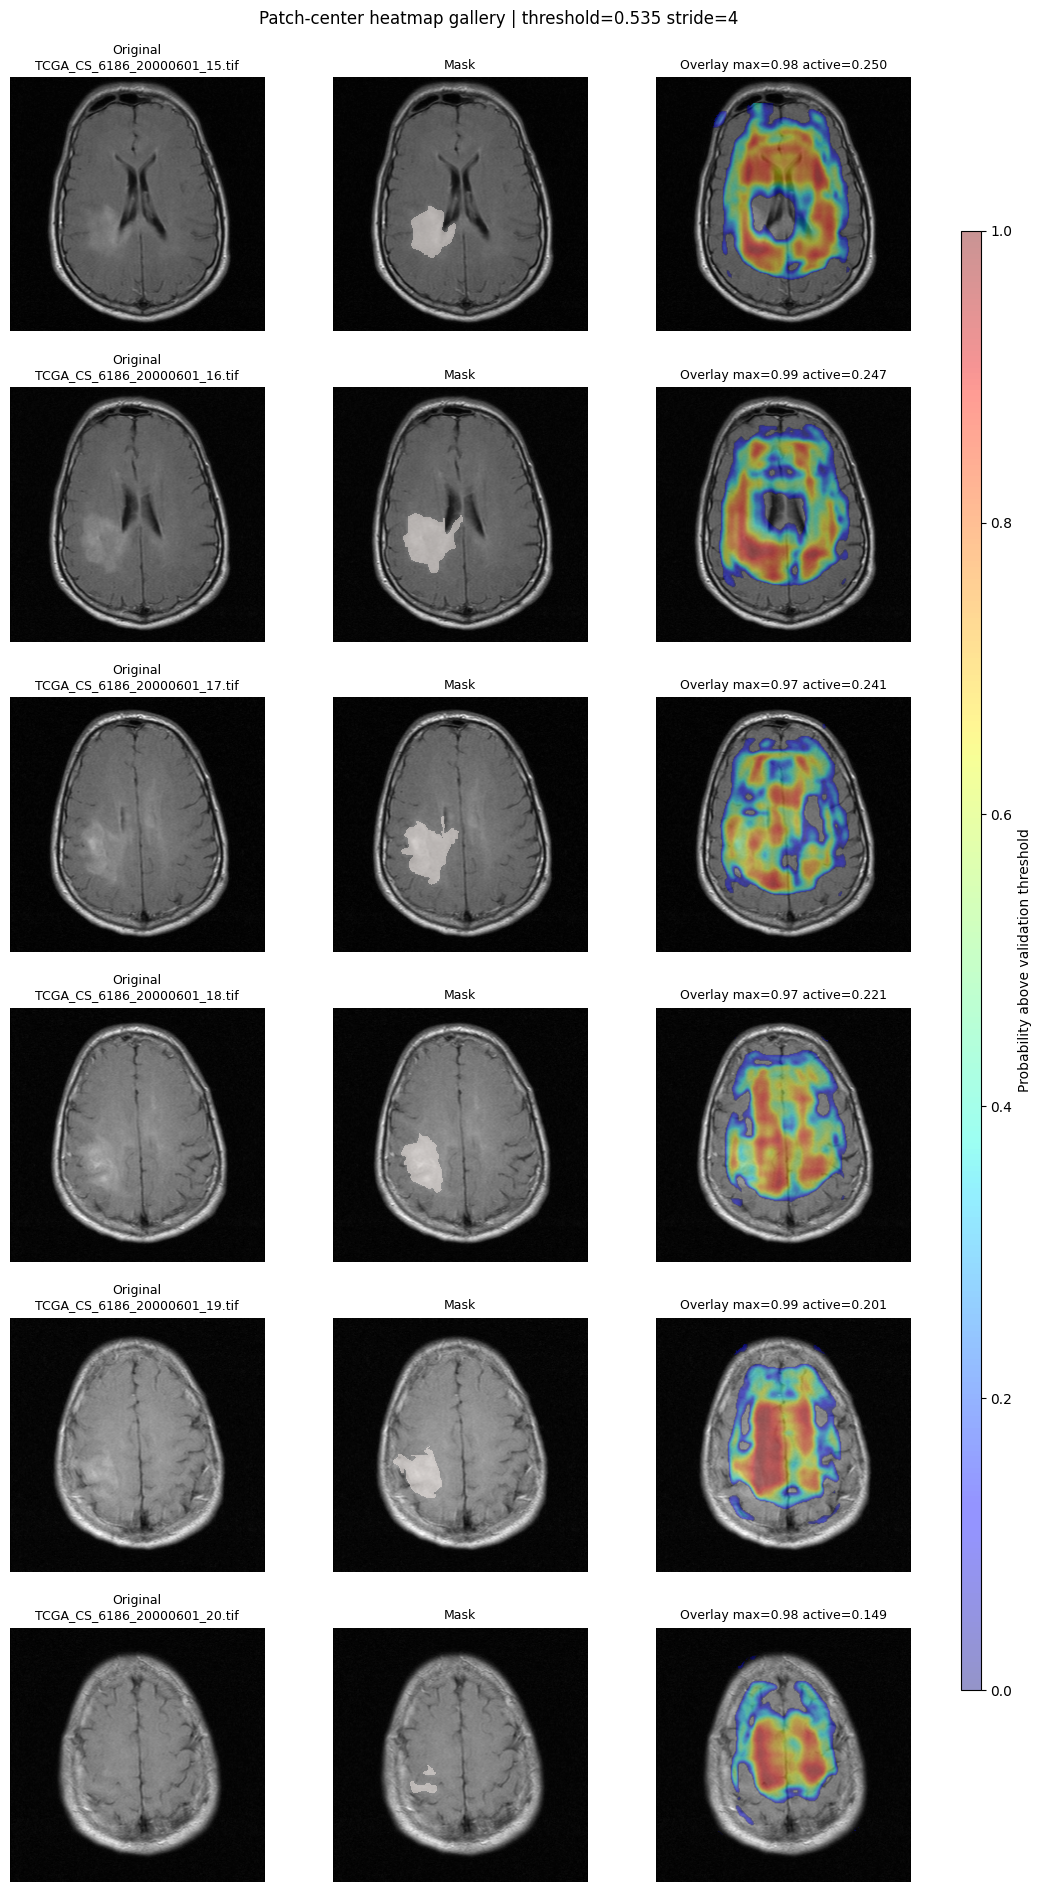

Saved heatmap gallery and first-example maps to results/brain2_radial_single_kernel


In [23]:
def find_example_pair(example_path=None):
    pairs = list_image_mask_pairs(DATASET_ROOT)
    if example_path is not None:
        p = Path(example_path)
        if p.is_file():
            mask = p.with_name(f"{p.stem}_mask.tif")
            if not mask.exists() and p.name.endswith("_mask.tif"):
                raise ValueError("EXAMPLE_IMAGE_PATH should point to an image .tif, not a mask .tif")
            if not mask.exists():
                raise FileNotFoundError(f"Mask not found for {p}: expected {mask}")
            return {"patient": p.parent.name, "image": p, "mask": mask, "stem": p.stem}

    split_by_patient = split_patients(pairs, TRAIN_FRAC, VAL_FRAC, SPLIT_SEED)
    preferred = []
    for split in ("test", "val", "train"):
        preferred.extend([row for row in pairs if split_by_patient[row["patient"]] == split])
    for row in preferred:
        mask = mask_to_bool(row["mask"])
        if mask.any():
            return row
    return preferred[0]


def heatmap_response_features(x_t: torch.Tensor, kernel_np: np.ndarray, batch_size: int):
    kernel_t = torch.from_numpy(kernel_np.astype(np.float32)).to(DEVICE)
    if kernel_t.ndim == 2:
        return extract_response_features(x_t, kernel_t, batch_size=batch_size)
    if kernel_t.ndim == 3:
        return extract_bank_features(x_t, kernel_t, batch_size=batch_size)
    raise ValueError(f"Expected 2D kernel or 3D kernel bank, got shape={tuple(kernel_t.shape)}")


def exact_patch_probability_map(img_arr: np.ndarray, kernel_np: np.ndarray, stride: int = 4, batch_size: int = 256):
    """Evaluate the same patch classifier used in training and assign scores to patch centers."""
    h, w = img_arr.shape
    patch_size = int(RESIZE_PATCH)
    stride = int(stride)
    if h < patch_size or w < patch_size:
        raise ValueError(f"Image {img_arr.shape} is smaller than patch size {patch_size}")

    y0s = list(range(0, h - patch_size + 1, stride))
    x0s = list(range(0, w - patch_size + 1, stride))
    if y0s[-1] != h - patch_size:
        y0s.append(h - patch_size)
    if x0s[-1] != w - patch_size:
        x0s.append(w - patch_size)

    prob_grid = np.zeros((len(y0s), len(x0s)), dtype=np.float32)
    center_sum = np.zeros((h, w), dtype=np.float32)
    center_weight = np.zeros((h, w), dtype=np.float32)
    half = patch_size // 2

    patches = []
    coords = []
    for iy, y0 in enumerate(tqdm(y0s, desc="Exact heatmap rows")):
        for ix, x0 in enumerate(x0s):
            patches.append(img_arr[y0 : y0 + patch_size, x0 : x0 + patch_size].astype(np.float32))
            coords.append((iy, ix, min(h - 1, y0 + half), min(w - 1, x0 + half)))
            if len(patches) >= batch_size:
                xb = to_tensor_batch(np.stack(patches, axis=0), torch.device("cpu"))
                if STANDARDIZE_PATCHES:
                    xb = patch_standardize(xb)
                feat = heatmap_response_features(xb, kernel_np, batch_size=batch_size)
                probs = sigmoid_np((feat - calib_mu) / calib_std @ calib_w + calib_b).astype(np.float32)
                for (gy, gx, cy, cx), prob in zip(coords, probs):
                    prob_grid[gy, gx] = float(prob)
                    center_sum[cy, cx] += float(prob)
                    center_weight[cy, cx] += 1.0
                patches.clear()
                coords.clear()

    if patches:
        xb = to_tensor_batch(np.stack(patches, axis=0), torch.device("cpu"))
        if STANDARDIZE_PATCHES:
            xb = patch_standardize(xb)
        feat = heatmap_response_features(xb, kernel_np, batch_size=batch_size)
        probs = sigmoid_np((feat - calib_mu) / calib_std @ calib_w + calib_b).astype(np.float32)
        for (gy, gx, cy, cx), prob in zip(coords, probs):
            prob_grid[gy, gx] = float(prob)
            center_sum[cy, cx] += float(prob)
            center_weight[cy, cx] += 1.0

    # Interpolate sparse center scores without pretending patch top-left positions are pixels.
    sigma = max(1.0, float(stride) / 2.0)
    smooth_sum = gaussian_filter(center_sum, sigma=sigma)
    smooth_weight = gaussian_filter(center_weight, sigma=sigma)
    prob_map = np.divide(smooth_sum, smooth_weight, out=np.zeros_like(smooth_sum), where=smooth_weight > 1e-8)
    valid_center_mask = smooth_weight > (0.01 * float(smooth_weight.max()) if smooth_weight.max() > 0 else 0.0)
    return prob_map.astype(np.float32), prob_grid, valid_center_mask


def prepare_heatmap_display(img_arr: np.ndarray, prob_map: np.ndarray, valid_center_mask: np.ndarray):
    prob_map_vis = gaussian_filter(prob_map, sigma=float(HEATMAP_SMOOTH_SIGMA)) if HEATMAP_SMOOTH_SIGMA > 0 else prob_map
    tissue_display = img_arr > (float(TISSUE_THRESHOLD) / 255.0)
    tissue_display = binary_erosion(tissue_display, iterations=1) if tissue_display.any() else tissue_display
    display_mask = tissue_display & valid_center_mask

    heatmap_threshold = float(results.get("threshold_val", 0.5))
    prob_map_conf = np.clip((prob_map_vis - heatmap_threshold) / max(1e-6, 1.0 - heatmap_threshold), 0.0, 1.0)
    prob_map_display_scaled = prob_map_conf * display_mask.astype(np.float32)
    active_display = display_mask & (prob_map_vis >= heatmap_threshold)

    score_max = float(prob_map[display_mask].max()) if display_mask.any() else float(prob_map.max())
    score_mean = float(prob_map[display_mask].mean()) if display_mask.any() else float(prob_map.mean())
    active_frac = float(active_display.mean())
    return {
        "prob_map_vis": prob_map_vis,
        "prob_map_display_scaled": prob_map_display_scaled,
        "active_display": active_display,
        "display_mask": display_mask,
        "heatmap_threshold": heatmap_threshold,
        "score_max": score_max,
        "score_mean": score_mean,
        "active_frac": active_frac,
    }


def select_heatmap_examples(n_examples: int):
    pairs = list_image_mask_pairs(DATASET_ROOT)
    split_by_patient = split_patients(pairs, TRAIN_FRAC, VAL_FRAC, SPLIT_SEED)
    selected = []

    if EXAMPLE_IMAGE_PATH is not None:
        selected.append(find_example_pair(EXAMPLE_IMAGE_PATH))

    for split in ("test", "val", "train"):
        for row in pairs:
            if len(selected) >= int(n_examples):
                return selected
            if split_by_patient[row["patient"]] != split:
                continue
            if any(row["image"] == prev["image"] for prev in selected):
                continue
            mask = mask_to_bool(row["mask"])
            if mask.any():
                selected.append(row)
    return selected


def compute_heatmap_for_example(example_row):
    img = image_to_gray_float(example_row["image"])
    mask = mask_to_bool(example_row["mask"], shape=img.shape)
    prob_map, prob_grid, valid_center_mask = exact_patch_probability_map(
        img,
        kernel_best,
        stride=EXACT_HEATMAP_STRIDE,
        batch_size=max(BATCH_SIZE, 256),
    )
    display = prepare_heatmap_display(img, prob_map, valid_center_mask)
    return img, mask, prob_map, prob_grid, display


examples = select_heatmap_examples(HEATMAP_N_EXAMPLES)
print(f"Rendering {len(examples)} heatmap examples")

# Detailed view for the first example, same layout as before.
example = examples[0]
example_img, example_mask, prob_map, prob_grid, display = compute_heatmap_for_example(example)
prob_map_display_scaled = display["prob_map_display_scaled"]
active_display = display["active_display"]
score_max = display["score_max"]
score_mean = display["score_mean"]
active_frac = display["active_frac"]
heatmap_threshold = display["heatmap_threshold"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes[0].imshow(example_img, cmap="gray")
axes[0].set_title(f"Original\n{example['image'].name}")
axes[0].axis("off")

axes[1].imshow(example_img, cmap="gray")
axes[1].imshow(np.ma.masked_where(~example_mask, example_mask), cmap="Reds", alpha=0.45, interpolation="nearest")
axes[1].set_title("Ground-truth mask")
axes[1].axis("off")

axes[2].imshow(example_img, cmap="gray")
im = axes[2].imshow(
    np.ma.masked_where(~active_display, prob_map_display_scaled),
    cmap="jet",
    alpha=DENSE_OVERLAY_ALPHA,
    vmin=0.0,
    vmax=1.0,
    interpolation="bilinear",
)
axes[2].set_title(f"Patch-center overlay >= {heatmap_threshold:.2f}\nmax={score_max:.3f} active={active_frac:.3f}")
axes[2].axis("off")

axes[3].imshow(np.ma.masked_where(~active_display, prob_map_display_scaled), cmap="jet", vmin=0.0, vmax=1.0, interpolation="bilinear")
axes[3].set_title(f"Patch-center heatmap\nstride={EXACT_HEATMAP_STRIDE}, grid={prob_grid.shape}")
axes[3].axis("off")

fig.suptitle(
    "Brain2 learned radial kernel inference | "
    f"Test AUC={results['test_05']['auc']:.3f} "
    f"Test ACC@0.5={results['test_05']['acc']:.3f} "
    f"Test ACC@thr_val={results['test_tuned']['acc']:.3f}",
    y=1.03,
)
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.82)
cbar.set_label("Probability above validation threshold")
fig.subplots_adjust(top=0.82, wspace=0.05)
plt.show()

print(
    f"Patch-center heatmap raw probability: max={score_max:.6f} "
    f"mean={score_mean:.6f} active_frac={active_frac:.6f} grid={prob_grid.shape}"
)

# Gallery view across multiple slices.
gallery_rows = []
for row in examples:
    img, mask, pmap, pgrid, disp = compute_heatmap_for_example(row)
    gallery_rows.append((row, img, mask, pmap, pgrid, disp))

fig, axes = plt.subplots(len(gallery_rows), 3, figsize=(11, 3.2 * len(gallery_rows)))
if len(gallery_rows) == 1:
    axes = np.array([axes])
last_im = None
for r, (row, img, mask, pmap, pgrid, disp) in enumerate(gallery_rows):
    overlay = disp["prob_map_display_scaled"]
    active = disp["active_display"]
    axes[r, 0].imshow(img, cmap="gray")
    axes[r, 0].set_title(f"Original\n{row['image'].name}", fontsize=9)
    axes[r, 0].axis("off")

    axes[r, 1].imshow(img, cmap="gray")
    axes[r, 1].imshow(np.ma.masked_where(~mask, mask), cmap="Reds", alpha=0.45, interpolation="nearest")
    axes[r, 1].set_title("Mask", fontsize=9)
    axes[r, 1].axis("off")

    axes[r, 2].imshow(img, cmap="gray")
    last_im = axes[r, 2].imshow(
        np.ma.masked_where(~active, overlay),
        cmap="jet",
        alpha=DENSE_OVERLAY_ALPHA,
        vmin=0.0,
        vmax=1.0,
        interpolation="bilinear",
    )
    axes[r, 2].set_title(
        f"Overlay max={disp['score_max']:.2f} active={disp['active_frac']:.3f}",
        fontsize=9,
    )
    axes[r, 2].axis("off")

fig.suptitle(
    f"Patch-center heatmap gallery | threshold={float(results.get('threshold_val', 0.5)):.3f} "
    f"stride={EXACT_HEATMAP_STRIDE}",
    y=0.995,
)
fig.subplots_adjust(left=0.03, right=0.90, top=0.96, bottom=0.02, wspace=0.04, hspace=0.22)
if last_im is not None:
    cax = fig.add_axes([0.92, 0.12, 0.018, 0.76])
    fig.colorbar(last_im, cax=cax, label="Probability above validation threshold")
plt.show()

if SAVE_ARTIFACTS:
    np.save(OUT_DIR / f"{example['stem']}_learned_radial_prob_map.npy", prob_map.astype(np.float32))
    np.save(OUT_DIR / f"{example['stem']}_learned_radial_prob_grid.npy", prob_grid.astype(np.float32))
    fig.savefig(OUT_DIR / "heatmap_gallery.png", dpi=260, bbox_inches="tight")
    print(f"Saved heatmap gallery and first-example maps to {OUT_DIR}")
